# V2 + SpecBoost-FNO (Residual Correction)

This notebook loads the **best trained v2 model** and trains a **residual correction model** (SpecBoost-FNO) on top of it.

**Reference:** "Toward a Better Understanding of Fourier Neural Operators from a Spectral Perspective" (2024)

FNO has an inherent Fourier parameterization bias: it excels at learning dominant frequencies but neglects non-dominant ones. SpecBoost corrects this by training a second model on the **residuals** (prediction errors) of the primary model.

Final prediction: `pred = primary_model(x) + residual_model(x)`

**Prerequisites:** Run `fno-v2-tier2.ipynb` first to train the primary model. The best model should be in `./runs/v2/run_XXX/best_model.pth`.

In [1]:
import numpy as np
import pandas as pd
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from natsort import natsorted
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.backends.cudnn.benchmark = True

PyTorch version: 2.10.0.dev20251204+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
GPU Memory: 12.8 GB


## 1. Data Loading (pre-processed)

In [2]:
def load_data(data_path):
    data = np.load(data_path, allow_pickle=True).item()
    return data

def get_mean_std(data_folder_path):
    data_list = []
    file_path = os.path.join(data_folder_path, "data_*.npy")
    file_names = glob.glob(file_path)
    file_names = natsorted(file_names)
    for file_name in file_names:
        data = load_data(file_name)
        data_list.append(data.get("field_node"))
    data = np.concatenate(data_list, axis=0)
    mean = np.mean(data, axis=0, keepdims=True)
    std = np.std(data, axis=0, keepdims=True)
    return mean, std

mean, std = get_mean_std("./elec-70127-fno/data/train/")
data_root = "./working/"
print(f"Mean shape: {mean.shape}, Std shape: {std.shape}")

Mean shape: (1, 3), Std shape: (1, 3)


In [3]:
class CNNDataset(Dataset):
    """Tier 2 Dataset with positional encoding + mask (6 input channels)."""

    def __init__(self, dataset_dir=None, t_dim=10, transform=None, target_transform=None):
        self.t_dim = t_dim
        self.transform = transform
        self.target_transform = target_transform
        self.file_names = glob.glob(os.path.join(dataset_dir, "data_*.npy"))
        self.file_names = natsorted(self.file_names)

    def __len__(self):
        return len(self.file_names) // (2 * self.t_dim)

    def load_data(self, data_path):
        return np.load(data_path, allow_pickle=True).item()

    def __getitem__(self, idx):
        start_idx = idx * 2 * self.t_dim

        in_list = []
        mask = None
        for i in range(self.t_dim):
            data = self.load_data(self.file_names[start_idx + i])
            in_list.append(data.get("field_conv"))
            if mask is None:
                mask = data.get("mask")

        out_list = []
        for i in range(self.t_dim):
            data = self.load_data(self.file_names[start_idx + self.t_dim + i])
            out_list.append(data.get("field_conv"))

        in_data = np.stack(in_list, axis=-1)
        out_data = np.stack(out_list, axis=-1)

        if self.transform:
            in_data = self.transform(in_data)
        if self.target_transform:
            out_data = self.target_transform(out_data)

        if isinstance(in_data, torch.Tensor):
            in_data = in_data.permute(1, 2, 3, 0)
            out_data = out_data.permute(1, 2, 3, 0)
        else:
            in_data = np.transpose(in_data, (1, 2, 3, 0))
            out_data = np.transpose(out_data, (1, 2, 3, 0))

        H, W, T = 80, 320, self.t_dim
        x_pos = np.broadcast_to(np.linspace(0, 1, W).reshape(1, W, 1), (H, W, T)).copy()
        y_pos = np.broadcast_to(np.linspace(0, 1, H).reshape(H, 1, 1), (H, W, T)).copy()
        mask_t = np.broadcast_to(mask[0, :, :, np.newaxis], (H, W, T)).copy()

        x_pos_t = torch.from_numpy(x_pos).float().unsqueeze(-1)
        y_pos_t = torch.from_numpy(y_pos).float().unsqueeze(-1)
        mask_t_t = torch.from_numpy(mask_t).float().unsqueeze(-1)

        if isinstance(in_data, torch.Tensor):
            in_data = torch.cat([in_data, x_pos_t, y_pos_t, mask_t_t], dim=-1)
        else:
            in_data = torch.from_numpy(in_data).float()
            in_data = torch.cat([in_data, x_pos_t, y_pos_t, mask_t_t], dim=-1)

        if not isinstance(out_data, torch.Tensor):
            out_data = torch.from_numpy(out_data).float()

        return in_data, out_data

In [4]:
class Normalise:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std
    def __call__(self, data):
        return (data - self.mean) / self.std

class ToFloatTransform:
    def __init__(self, scale=True):
        return
    def __call__(self, data):
        return torch.from_numpy(data).float()

class Compose:
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, data):
        for transform in self.transforms:
            data = transform(data)
        return data

transform = Compose([
    Normalise(mean=mean.reshape(-1, 1, 1, 1), std=std.reshape(-1, 1, 1, 1)),
    ToFloatTransform(),
])

train_set = CNNDataset(dataset_dir=f"{data_root}/train/", transform=transform, target_transform=transform)
test_set = CNNDataset(dataset_dir=f"{data_root}/test/", transform=transform, target_transform=transform)

print(f"Train samples: {len(train_set)}, Test samples: {len(test_set)}")
print(f"Sample shape: {train_set[0][0].shape} -> {train_set[0][1].shape}")

Train samples: 150, Test samples: 25
Sample shape: torch.Size([80, 320, 10, 6]) -> torch.Size([80, 320, 10, 3])


## 2. Model Architecture

In [5]:
class SpectralConv3d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, modes3):
        super(SpectralConv3d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.modes3 = modes3

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))
        self.weights3 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))
        self.weights4 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3, dtype=torch.cfloat))

    def compl_mul3d(self, input, weights):
        return torch.einsum("bixyz,ioxyz->boxyz", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfftn(x, dim=[-3,-2,-1])
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-3), x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2, :self.modes3] = self.compl_mul3d(x_ft[:, :, :self.modes1, :self.modes2, :self.modes3], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2, :self.modes3] = self.compl_mul3d(x_ft[:, :, -self.modes1:, :self.modes2, :self.modes3], self.weights2)
        out_ft[:, :, :self.modes1, -self.modes2:, :self.modes3] = self.compl_mul3d(x_ft[:, :, :self.modes1, -self.modes2:, :self.modes3], self.weights3)
        out_ft[:, :, -self.modes1:, -self.modes2:, :self.modes3] = self.compl_mul3d(x_ft[:, :, -self.modes1:, -self.modes2:, :self.modes3], self.weights4)
        x = torch.fft.irfftn(out_ft, s=(x.size(-3), x.size(-2), x.size(-1)))
        return x


class FNO3d(nn.Module):
    def __init__(self, modes1=16, modes2=10, modes3=5, width=48, n_layers=6, in_channels=6):
        super(FNO3d, self).__init__()
        self.modes1 = modes1
        self.modes2 = modes2
        self.modes3 = modes3
        self.width = width
        self.n_layers = n_layers

        self.fc0 = nn.Linear(in_channels, self.width)
        self.spectral_convs = nn.ModuleList([
            SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
            for _ in range(n_layers)
        ])
        self.pointwise_convs = nn.ModuleList([
            nn.Conv1d(self.width, self.width, 1)
            for _ in range(n_layers)
        ])
        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        batchsize = x.shape[0]
        size_x, size_y, size_z = x.shape[1], x.shape[2], x.shape[3]
        x = self.fc0(x)
        x = x.permute(0, 4, 1, 2, 3)
        for i in range(self.n_layers):
            x1 = self.spectral_convs[i](x)
            x2 = self.pointwise_convs[i](x.reshape(batchsize, self.width, -1))
            x2 = x2.view(batchsize, self.width, size_x, size_y, size_z)
            x = x1 + x2
            if i < self.n_layers - 1:
                x = F.gelu(x)
        x = x.permute(0, 2, 3, 4, 1)
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)
        return x

## 3. Load Best V2 Primary Model

In [6]:
def get_run_dir(version="v2-specboost"):
    """Create a new numbered run directory."""
    base = f"./runs/{version}"
    os.makedirs(base, exist_ok=True)
    existing = [d for d in os.listdir(base) if d.startswith("run_")]
    run_num = len(existing) + 1
    run_dir = os.path.join(base, f"run_{run_num:03d}")
    os.makedirs(run_dir, exist_ok=True)
    print(f"Saving to: {run_dir}")
    return run_dir


def get_latest_run_dir(version="v2-specboost"):
    """Find the latest run directory for a given version."""
    base = f"./runs/{version}"
    if not os.path.exists(base):
        return "."
    existing = sorted([d for d in os.listdir(base) if d.startswith("run_")])
    if not existing:
        return "."
    return os.path.join(base, existing[-1])


def load_model(model, weight_path, strict=False):
    try:
        model.load_state_dict(torch.load(weight_path), strict=strict)
    except RuntimeError:
        state_dict = torch.load(weight_path, map_location=device)
        model.load_state_dict(state_dict, strict=strict)
    return model


# Find the best v2 model
v2_base = "./runs/v2"
v2_runs = sorted([d for d in os.listdir(v2_base) if d.startswith("run_")])
v2_run_dir = os.path.join(v2_base, v2_runs[-1])
v2_weight_path = os.path.join(v2_run_dir, "best_model.pth")

print(f"Loading primary model from: {v2_weight_path}")
primary_model = FNO3d(modes1=16, modes2=10, modes3=5, width=48, n_layers=6, in_channels=6)
primary_model = load_model(primary_model, v2_weight_path)
primary_model = primary_model.to(device)
primary_model.eval()

total_params = sum(p.numel() for p in primary_model.parameters())
print(f"Primary model params: {total_params:,}")

Loading primary model from: ./runs/v2\run_009\best_model.pth
Primary model params: 44,257,907


## 4. Evaluate Primary Model (baseline)

In [7]:
def denormalise(data, mean, std):
    return data * std + mean

def normalise(data, mean, std):
    return (data - mean) / std

def calc_norm_error(pred, truth, ord=2):
    pred, truth = [vec.flatten() for vec in [pred, truth]]
    nume = torch.linalg.norm((pred - truth), ord=ord)
    deno = torch.linalg.norm(truth, ord=ord)
    return nume / deno

def calculate_error_and_inference(dataloader, model, mean, std):
    model.to(device)
    model.eval()
    error = 0.0
    pred_list = []
    ground_list = []
    with torch.no_grad():
        for batch in dataloader:
            data_in, target = batch
            data_in, target = data_in.to(device), target.to(device)
            pred = model(data_in)
            pred, target = denormalise(pred, mean, std), denormalise(target, mean, std)
            pred_list.append(pred.detach().cpu().numpy())
            ground_list.append(target.detach().cpu().numpy())
            error_i = calc_norm_error(pred, target)
            error += error_i.detach()
    error /= (len(dataloader) * dataloader.batch_size)
    return error, pred_list, ground_list


test_loader = DataLoader(test_set, batch_size=1, num_workers=0, pin_memory=True)

mean_t = torch.tensor(mean.reshape(1, 1, 1, 1, -1)).to(device)
std_t = torch.tensor(std.reshape(1, 1, 1, 1, -1)).to(device)

error_primary, _, _ = calculate_error_and_inference(test_loader, primary_model, mean_t, std_t)
print(f"Primary V2 model - Relative L2 Error: {error_primary:.6f}")

Primary V2 model - Relative L2 Error: 0.005380


## 5. Residual Dataset (SpecBoost)

In [8]:
class ResidualDataset(Dataset):
    """
    Dataset that computes residuals from a base model.
    The residual model learns: target - base_model(input),
    i.e., what the primary model fails to capture.
    """
    def __init__(self, base_dataset, base_model, device):
        self.base_dataset = base_dataset
        self.base_model = base_model
        self.device = device
        self.base_model.eval()

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        in_data, out_data = self.base_dataset[idx]
        with torch.no_grad():
            in_tensor = in_data.unsqueeze(0).to(self.device)
            base_pred = self.base_model(in_tensor).squeeze(0).cpu()
        residual = out_data - base_pred
        return in_data, residual


residual_train = ResidualDataset(train_set, primary_model, device)
residual_test = ResidualDataset(test_set, primary_model, device)

# Check residual magnitude
sample_in, sample_res = residual_train[0]
_, sample_target = train_set[0]
print(f"Target norm: {torch.norm(sample_target):.4f}")
print(f"Residual norm: {torch.norm(sample_res):.4f}")
print(f"Residual/Target ratio: {torch.norm(sample_res)/torch.norm(sample_target):.4f}")

Target norm: 664.9589
Residual norm: 36.0841
Residual/Target ratio: 0.0543


## 6. Train Residual Model

In [9]:
class H1SobolevLoss(torch.nn.Module):
    """H1 Sobolev loss with spatial gradient penalty."""
    def __init__(self, alpha=0.1):
        super().__init__()
        self.alpha = alpha

    def _rel_l2(self, a, b):
        return torch.norm(a - b) / (torch.norm(b) + 1e-8)

    def forward(self, pred, target):
        l2 = self._rel_l2(pred, target)
        dx_pred = pred[:, 1:, :, :, :] - pred[:, :-1, :, :, :]
        dx_target = target[:, 1:, :, :, :] - target[:, :-1, :, :, :]
        dy_pred = pred[:, :, 1:, :, :] - pred[:, :, :-1, :, :]
        dy_target = target[:, :, 1:, :, :] - target[:, :, :-1, :, :]
        grad_loss = self._rel_l2(dx_pred, dx_target) + self._rel_l2(dy_pred, dy_target)
        return l2 + self.alpha * grad_loss


def train_one_epoch(model, loader, optimizer, criterion, noise_std=0.01):
    model.train()
    avg_loss = 0.0
    for batch in tqdm(loader, desc="Training", leave=False):
        in_data, out_data = batch
        in_data, out_data = in_data.to(device, non_blocking=True), out_data.to(device, non_blocking=True)
        noise = torch.zeros_like(in_data)
        noise[..., :3] = noise_std * torch.randn_like(in_data[..., :3])
        in_data = in_data + noise
        optimizer.zero_grad()
        pred = model(in_data)
        loss = criterion(pred, out_data)
        loss.backward()
        optimizer.step()
        avg_loss += loss.item()
    avg_loss /= len(loader)
    return avg_loss, model


def test_one_epoch(model, loader, criterion):
    model.eval()
    avg_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing", leave=False):
            in_data, out_data = batch
            in_data, out_data = in_data.to(device, non_blocking=True), out_data.to(device, non_blocking=True)
            pred = model(in_data)
            loss = criterion(pred, out_data)
            avg_loss += loss.item()
    avg_loss /= len(loader)
    return avg_loss


def plot_losses(train_losses, test_losses, test_epochs, run_dir, title="Training & Test Loss", filename="loss_plot.png"):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", alpha=0.8)
    if test_losses:
        ax.plot(test_epochs, test_losses, 'o-', label="Test Loss", alpha=0.8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale("log")
    fig.tight_layout()
    fig.savefig(os.path.join(run_dir, filename), dpi=150)
    plt.show()
    plt.close(fig)

Residual model params: 1,777,475 (vs primary: 44,257,907)
Saving to: ./runs/v2-specboost\run_004


Residual Epochs:   0%|          | 1/200 [00:13<43:42, 13.18s/it]

Epoch 	1, Train Loss 	4.480865, LR 	0.000500


Residual Epochs:   1%|          | 2/200 [00:26<43:10, 13.08s/it]

Epoch 	2, Train Loss 	1.434285, LR 	0.000500


...

Residual Epochs: 100%|█████████▉| 199/200 [48:10<00:14, 14.61s/it]

Epoch 	199, Train Loss 	1.198473, LR 	0.000001


Epoch 	200, Train Loss 	1.198471, LR 	0.000001


Residual Epochs: 100%|██████████| 200/200 [48:26<00:00, 14.53s/it]


	 Epoch 	200, Test Loss 	1.199196


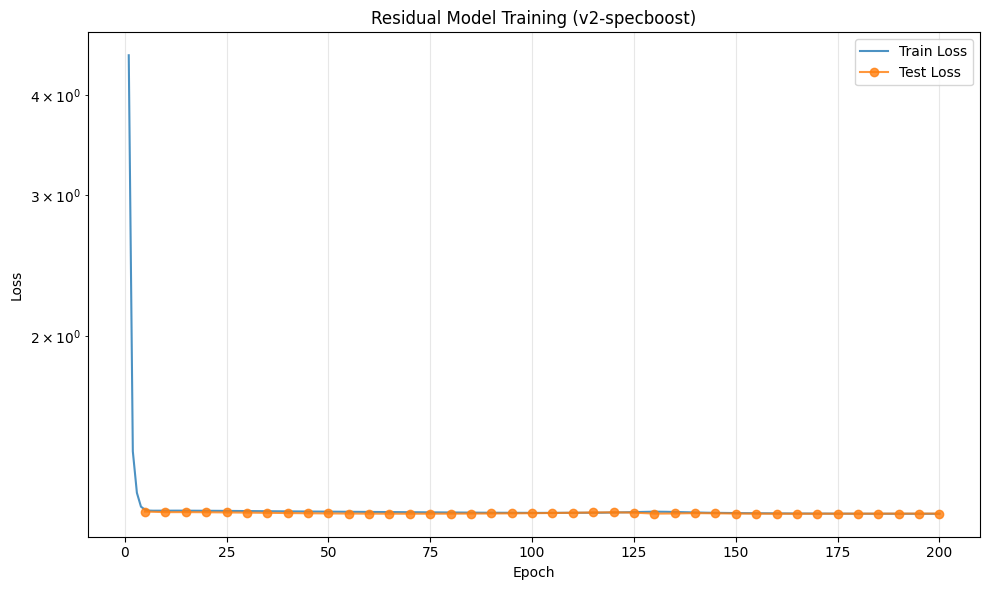

Training complete. Best test loss: 1.198699, saved in ./runs/v2-specboost\run_004


In [10]:
# =============================================================================
# Train residual correction model
# Smaller architecture: 3 layers, width=32, fewer modes
# =============================================================================

residual_epoch = 200
residual_lr = 5e-4
residual_bs = 8

residual_loader_train = DataLoader(residual_train, batch_size=residual_bs, num_workers=0, pin_memory=True)
residual_loader_test = DataLoader(residual_test, batch_size=residual_bs, num_workers=0, pin_memory=True)

residual_model = FNO3d(modes1=8, modes2=6, modes3=3, width=32, n_layers=3, in_channels=6)
residual_params = sum(p.numel() for p in residual_model.parameters())
print(f"Residual model params: {residual_params:,} (vs primary: {total_params:,})")

residual_optimizer = torch.optim.Adam(residual_model.parameters(), lr=residual_lr, weight_decay=1e-4)
residual_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(residual_optimizer, T_max=residual_epoch, eta_min=1e-6)

# Create run directory for this specboost run
current_run_dir = get_run_dir("v2-specboost")

# Save reference to which v2 model was used
with open(os.path.join(current_run_dir, "config.txt"), "w") as f:
    f.write(f"primary_model: {v2_weight_path}\n")
    f.write(f"residual_epochs: {residual_epoch}\n")
    f.write(f"residual_lr: {residual_lr}\n")
    f.write(f"residual_bs: {residual_bs}\n")
    f.write(f"residual_arch: modes1=8, modes2=6, modes3=3, width=32, n_layers=3\n")

# Training loop
criterion = H1SobolevLoss(alpha=0.1)
residual_model = residual_model.to(device)
best_test_loss = float("inf")
train_losses = []
test_losses = []
test_epochs = []

for i in tqdm(range(residual_epoch), desc="Residual Epochs"):
    loss, residual_model = train_one_epoch(
        model=residual_model, loader=residual_loader_train,
        optimizer=residual_optimizer, criterion=criterion)
    train_losses.append(loss)
    residual_scheduler.step()
    lr_current = residual_optimizer.param_groups[0]['lr']
    print(f"Epoch \t{i+1}, Train Loss \t{loss:.6f}, LR \t{lr_current:.6f}")
    if (i+1) % 5 == 0:
        info = test_one_epoch(model=residual_model, loader=residual_loader_test, criterion=criterion)
        test_losses.append(info)
        test_epochs.append(i + 1)
        print(f"\t Epoch \t{i+1}, Test Loss \t{info:.6f}")
        if info < best_test_loss:
            best_test_loss = info
            torch.save(residual_model.state_dict(), os.path.join(current_run_dir, "best_residual.pth"))
            print(f"\t >> New best residual model saved (test loss: {info:.6f})")
        torch.save(residual_model.state_dict(), os.path.join(current_run_dir, f"epoch_{i+1}.pth"))

plot_losses(train_losses, test_losses, test_epochs, current_run_dir,
            title="Residual Model Training (v2-specboost)", filename="loss_plot_residual.png")
print(f"Training complete. Best test loss: {best_test_loss:.6f}, saved in {current_run_dir}")

## 7. Evaluate Ensemble (Primary + Residual)

In [11]:
def calculate_ensemble_error(dataloader, primary_model, residual_model, mean_t, std_t):
    """Evaluate the SpecBoost ensemble: pred = primary(x) + residual(x)"""
    primary_model.to(device).eval()
    residual_model.to(device).eval()
    error = 0.0
    pred_list = []
    ground_list = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Ensemble eval", leave=False):
            data_in, target = batch
            data_in, target = data_in.to(device, non_blocking=True), target.to(device, non_blocking=True)
            pred_primary = primary_model(data_in)
            pred_residual = residual_model(data_in)
            pred = pred_primary + pred_residual
            pred_dn = denormalise(pred, mean_t, std_t)
            target_dn = denormalise(target, mean_t, std_t)
            pred_list.append(pred_dn.detach().cpu().numpy())
            ground_list.append(target_dn.detach().cpu().numpy())
            error_i = calc_norm_error(pred_dn, target_dn)
            error += error_i.detach()
    error /= (len(dataloader) * dataloader.batch_size)
    return error, pred_list, ground_list


# Load best residual model
run_dir = current_run_dir if 'current_run_dir' in dir() else get_latest_run_dir("v2-specboost")
residual_model_eval = FNO3d(modes1=8, modes2=6, modes3=3, width=32, n_layers=3, in_channels=6)
residual_model_eval = load_model(residual_model_eval, os.path.join(run_dir, "best_residual.pth"))

test_loader = DataLoader(test_set, batch_size=1, num_workers=0, pin_memory=True)

# Primary only (baseline)
error_primary, _, _ = calculate_error_and_inference(test_loader, primary_model, mean_t, std_t)
print(f"Primary V2 only     - Relative L2 Error: {error_primary:.6f}")

# Ensemble (primary + residual)
error_ensemble, pred_ensemble, ground_ensemble = calculate_ensemble_error(
    test_loader, primary_model, residual_model_eval, mean_t, std_t)
print(f"V2 + SpecBoost      - Relative L2 Error: {error_ensemble:.6f}")

improvement = (error_primary - error_ensemble) / error_primary * 100
print(f"Improvement: {improvement:.1f}%")

Primary V2 only     - Relative L2 Error: 0.005380


V2 + SpecBoost      - Relative L2 Error: 0.005372
Improvement: 0.2%


## 8. Submission

In [12]:
def pred_to_df(data):
    reshaped = data.reshape(-1, 3)
    df = pd.DataFrame(reshaped, columns=['Feature_1', 'Feature_2', 'Feature_3'])
    df.index.name = "ROW_ID"
    return df


# Val_task3 inference with ensemble
file_dir = f"{data_root}/val_task3/"
file_names = glob.glob(os.path.join(file_dir, "data_*.npy"))
file_names = natsorted(file_names)

in_list = []
mask = None
for i in range(len(file_names)):
    data_i = load_data(file_names[i])
    field = data_i.get("field_conv")
    if mask is None:
        mask = data_i.get("mask")
    field = normalise(field, mean=mean.reshape(-1, 1, 1), std=std.reshape(-1, 1, 1))
    in_list.append(field)

in_data = np.stack(in_list, axis=-1)
in_data = np.transpose(in_data, (1, 2, 3, 0))

H, W, T = 80, 320, len(file_names)
x_pos = np.broadcast_to(np.linspace(0, 1, W).reshape(1, W, 1), (H, W, T)).copy()
y_pos = np.broadcast_to(np.linspace(0, 1, H).reshape(H, 1, 1), (H, W, T)).copy()
mask_t = np.broadcast_to(mask[0, :, :, np.newaxis], (H, W, T)).copy()

in_data = np.concatenate([
    in_data, x_pos[..., np.newaxis], y_pos[..., np.newaxis], mask_t[..., np.newaxis]
], axis=-1)

in_data = torch.tensor(in_data).unsqueeze(0).float().to(device)
print(f"Input shape: {in_data.shape}")

# Ensemble prediction
primary_model.to(device).eval()
residual_model_eval.to(device).eval()

with torch.no_grad():
    pred_primary = primary_model(in_data)
    pred_residual = residual_model_eval(in_data)
    pred = (pred_primary + pred_residual).detach().cpu().numpy()
    pred = denormalise(pred, mean, std)
print(f"Prediction shape: {pred.shape}")

Input shape: torch.Size([1, 80, 320, 10, 6])
Prediction shape: (1, 80, 320, 10, 3)


In [13]:
pred = np.stack(pred, axis=0)
print(pred.shape)

(1, 80, 320, 10, 3)


In [14]:
print(pred.shape)
pred_1 = np.stack(pred, axis=0)
run_dir = current_run_dir if 'current_run_dir' in dir() else get_latest_run_dir("v2-specboost")
np.save(os.path.join(run_dir, "pred_1.npy"), pred_1)
pred_to_df(pred_1).to_csv(os.path.join(run_dir, "submission.csv"), index=True)
print(f"Submission saved to: {os.path.join(run_dir, 'submission.csv')}")

(1, 80, 320, 10, 3)
Submission saved to: ./runs/v2-specboost\run_004\submission.csv


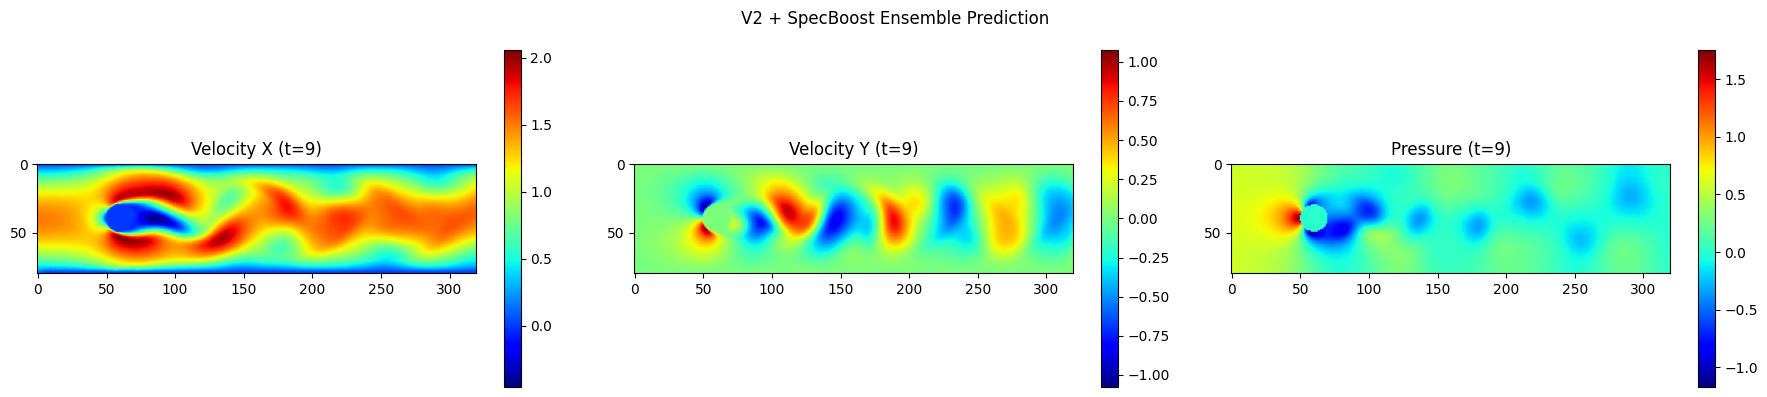

In [15]:
# Visualize prediction
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
channel_names = ["Velocity X", "Velocity Y", "Pressure"]
idx = 9  # last timestep
for c in range(3):
    im = axes[c].imshow(pred[0, :, :, idx, c], cmap="jet")
    axes[c].set_title(f"{channel_names[c]} (t={idx})")
    plt.colorbar(im, ax=axes[c])
fig.suptitle("V2 + SpecBoost Ensemble Prediction")
fig.tight_layout()
fig.savefig(os.path.join(run_dir, "prediction_visualization.png"), dpi=150)
plt.show()